In [1]:
import sys
sys.path.append('../')

import numpy as np
import torch
import matplotlib.pyplot as plt
from data_loader import PairData
from env_v2_07 import PairTradingEnv
from ddqn import DoubleDQN

SEED = 42
rng  = np.random.default_rng(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
# ── Data & cointegration (training data only) ────────────────────────────
data   = PairData('../../data/real_pair_MCD_YUM.csv')
prices = data.s
N      = prices.shape[1]

train_end = 3 * N // 4

log_A = np.log(prices[0])
log_B = np.log(prices[1])

# OLS on training data only
X_ols = np.column_stack([np.ones(train_end), log_B[:train_end]])
coef, _, _, _ = np.linalg.lstsq(X_ols, log_A[:train_end], rcond=None)
intercept, beta = float(coef[0]), float(coef[1])

# Fixed normalisation stats from training spread
hist_spread = log_A[:train_end] - beta * log_B[:train_end] - intercept
train_mean  = float(hist_spread.mean())
train_std   = float(hist_spread.std())

print(f'N={N}  |  train [0, {train_end})  |  test [{train_end}, {N})')
print(f'beta={beta:.4f}  intercept={intercept:.4f}')
print(f'train_mean={train_mean:.6f}  train_std={train_std:.6f}')

N=5032  |  train [0, 3774)  |  test [3774, 5032)
beta=0.9830  intercept=0.6916
train_mean=0.000000  train_std=0.111219


In [3]:
# ── AR(1) fit for synthetic generation ──────────────────────────────────
def fit_ar1(series):
    y = series[1:]
    X = np.column_stack([np.ones(len(y)), series[:-1]])
    c, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    return float(c[0]), float(c[1]), float(np.std(y - X @ c))

def fit_gbm(log_prices):
    r = np.diff(log_prices)
    return float(r.mean()), float(r.std())

alpha_s, phi_s, sigma_s = fit_ar1(hist_spread)
mu_A,    sigma_A        = fit_gbm(log_A[:train_end])

half_life = -np.log(2) / np.log(phi_s)
print(f'AR(1):  phi={phi_s:.6f}  sigma={sigma_s:.6f}')
print(f'  Half-life: {half_life:.1f} days  (used as-is for synthetic generation)')

AR(1):  phi=0.991731  sigma=0.013848
  Half-life: 83.5 days  (used as-is for synthetic generation)


In [4]:
# ── Episode generators ────────────────────────────────────────────────────
EPISODE_LEN = 300
EP_LEN_FULL = 3 + EPISODE_LEN   # 303: 3-step vel warmup + 300 tradeable steps

def gen_synthetic(init_logA, init_spread):
    """Generate (2, 303) synthetic prices using AR(1) spread + GBM stock A."""
    eps_s = rng.normal(0,    sigma_s, EP_LEN_FULL)
    eps_A = rng.normal(mu_A, sigma_A, EP_LEN_FULL)

    spread = np.empty(EP_LEN_FULL)
    log_A_ = np.empty(EP_LEN_FULL)
    spread[0] = init_spread
    log_A_[0] = init_logA

    for t in range(1, EP_LEN_FULL):
        spread[t] = alpha_s + phi_s * spread[t-1] + eps_s[t]
        log_A_[t] = log_A_[t-1] + eps_A[t]

    log_B_ = (log_A_ - spread - intercept) / beta
    return np.array([np.exp(log_A_), np.exp(log_B_)])


def sample_real(t0):
    """Slice (2, 303) real prices starting at t0."""
    return prices[:, t0 : t0 + EP_LEN_FULL]


# Valid start range for real episodes
REAL_T_MAX = train_end - EP_LEN_FULL   # latest start that fits in training data

print(f'Episode length: {EPISODE_LEN} steps  |  total slice: {EP_LEN_FULL} pts')
print(f'Real episode start range: [0, {REAL_T_MAX}]  ({REAL_T_MAX+1} options)')

Episode length: 300 steps  |  total slice: 303 pts
Real episode start range: [0, 3471]  (3472 options)


In [5]:
# ── Agent ─────────────────────────────────────────────────────────────────
agent = DoubleDQN(
    state_dim       = 4,
    action_dim      = 3,
    hidden          = 64,
    lr              = 3e-4,
    gamma           = 0.99,
    tau             = 0.005,
    buffer_size     = int(1e6),
    batch_size      = 256,
    eps_start       = 1.0,
    eps_end         = 0.05,
    eps_decay_steps = 600_000,
    grad_clip       = 1.0,
)
print(f'Agent ready.  Initial epsilon: {agent.epsilon:.3f}')

Agent ready.  Initial epsilon: 1.000


In [6]:
# ── Training loop — 50 % synthetic / 50 % real ───────────────────────────
N_EPISODES  = 2000
TRAIN_FREQ  = 4
LOG_EVERY   = 100

ep_rewards  = []
ep_wealth   = []
ep_eps      = []
ep_types    = []   # 'S' or 'R'
losses      = []
total_steps = 0

env_kw = dict(beta=beta, intercept=intercept, z_mean=train_mean, z_std=train_std,
              episode_len=EPISODE_LEN)

for ep in range(N_EPISODES):
    if rng.random() < 0.5:
        # Synthetic episode
        t_init      = int(rng.integers(0, train_end))
        init_logA   = float(log_A[t_init])
        init_spread = float(hist_spread[t_init])
        prices_ep   = gen_synthetic(init_logA, init_spread)
        ep_type     = 'S'
    else:
        # Real episode — random window from training data
        t0        = int(rng.integers(0, REAL_T_MAX + 1))
        prices_ep = sample_real(t0)
        ep_type   = 'R'

    env = PairTradingEnv(prices_ep, **env_kw)

    obs, _ = env.reset()
    done   = False
    ep_r   = 0.0

    while not done:
        action = agent.select_action(obs)
        next_obs, reward, done, _, _ = env.step(action)
        agent.replay_buffer.add(obs, action, reward, next_obs, done)
        obs  = next_obs
        ep_r += reward
        total_steps += 1

        if total_steps % TRAIN_FREQ == 0:
            loss = agent.train()
            if loss is not None:
                losses.append(loss)

    ep_rewards.append(ep_r)
    ep_wealth.append(env._wealth())
    ep_eps.append(agent.epsilon)
    ep_types.append(ep_type)

    if (ep + 1) % LOG_EVERY == 0:
        last = ep_types[-LOG_EVERY:]
        n_s  = last.count('S')
        avg_r = np.mean(ep_rewards[-LOG_EVERY:])
        avg_w = np.mean(ep_wealth[-LOG_EVERY:])
        print(f'ep {ep+1:5d} | avg_reward {avg_r:+8.2f} | avg_wealth {avg_w:8.2f} | '
              f'eps {agent.epsilon:.3f} | S/R {n_s}/{LOG_EVERY-n_s}')

ep   100 | avg_reward  +347.41 | avg_wealth 10347.41 | eps 0.953 | S/R 44/56
ep   200 | avg_reward  +632.93 | avg_wealth 10632.93 | eps 0.905 | S/R 48/52
ep   300 | avg_reward  +312.65 | avg_wealth 10312.65 | eps 0.858 | S/R 51/49
ep   400 | avg_reward  +537.73 | avg_wealth 10537.73 | eps 0.810 | S/R 48/52
ep   500 | avg_reward  +625.08 | avg_wealth 10625.08 | eps 0.762 | S/R 46/54
ep   600 | avg_reward  +554.14 | avg_wealth 10554.14 | eps 0.715 | S/R 50/50
ep   700 | avg_reward  +767.14 | avg_wealth 10767.14 | eps 0.667 | S/R 38/62
ep   800 | avg_reward  +857.31 | avg_wealth 10857.31 | eps 0.620 | S/R 52/48
ep   900 | avg_reward  +753.34 | avg_wealth 10753.34 | eps 0.573 | S/R 55/45
ep  1000 | avg_reward  +971.57 | avg_wealth 10971.57 | eps 0.525 | S/R 55/45
ep  1100 | avg_reward +1202.07 | avg_wealth 11202.07 | eps 0.477 | S/R 50/50
ep  1200 | avg_reward +1261.07 | avg_wealth 11261.07 | eps 0.430 | S/R 46/54
ep  1300 | avg_reward  +864.24 | avg_wealth 10864.24 | eps 0.382 | S/R 43/57

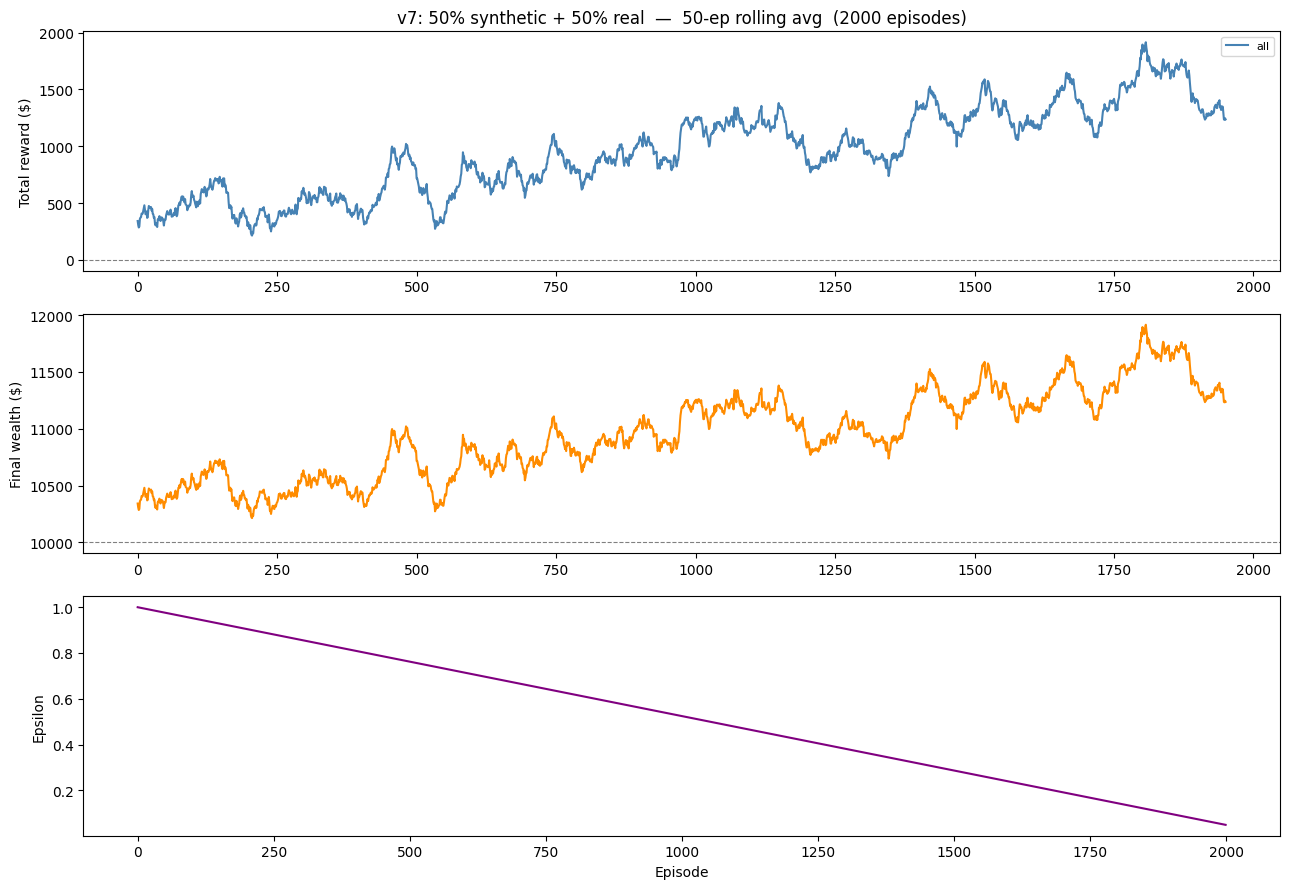

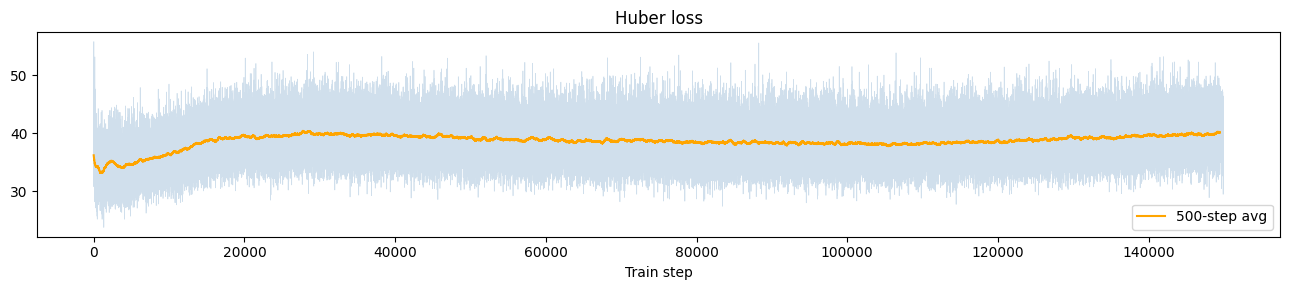

In [7]:
# ── Training curves ──────────────────────────────────────────────────────
roll = 50
kern = np.ones(roll) / roll

types_arr = np.array(ep_types)
syn_idx   = np.where(types_arr == 'S')[0]
real_idx  = np.where(types_arr == 'R')[0]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)

axes[0].plot(np.convolve(ep_rewards, kern, mode='valid'), color='steelblue', label='all')
axes[0].axhline(0, color='gray', lw=0.8, ls='--')
axes[0].set_ylabel('Total reward ($)')
axes[0].set_title(f'v7: 50% synthetic + 50% real  —  {roll}-ep rolling avg  ({N_EPISODES} episodes)')
axes[0].legend(fontsize=8)

axes[1].plot(np.convolve(ep_wealth, kern, mode='valid'), color='darkorange')
axes[1].axhline(10_000, color='gray', lw=0.8, ls='--')
axes[1].set_ylabel('Final wealth ($)')

axes[2].plot(ep_eps, color='purple')
axes[2].set_ylabel('Epsilon')
axes[2].set_xlabel('Episode')

plt.tight_layout()
plt.show()

if losses:
    fig, ax = plt.subplots(figsize=(13, 3))
    ax.plot(losses, alpha=0.25, lw=0.5, color='steelblue')
    smooth = np.convolve(losses, np.ones(500)/500, mode='valid')
    ax.plot(smooth, color='orange', lw=1.5, label='500-step avg')
    ax.set_title('Huber loss')
    ax.set_xlabel('Train step')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [8]:
# ── Evaluation helpers ───────────────────────────────────────────────────
_RF_DAILY = (1.05) ** (1.0 / 252) - 1

def evaluate(env, agent, t_start=None, t_end=None):
    if t_start is not None:
        env._t      = t_start
        env._end    = t_end if t_end is not None else env._N
        env._cash   = env.initial_wealth
        env._shares = np.zeros(2, dtype=np.float64)
        env._pos    = 0
        obs         = env._obs()
    else:
        obs, _ = env.reset()

    t0            = env._t
    wealth        = [env._wealth()]
    z_hist        = [float(obs[0])]
    pos_hist      = []
    entries_long  = []
    entries_short = []
    exits         = []
    step          = 0

    done = False
    while not done:
        prev_pos = env._pos
        action   = agent.select_action(obs, deterministic=True)
        obs, reward, done, _, _ = env.step(action)

        pos_hist.append(env._pos)
        wealth.append(env._wealth())
        z_hist.append(float(obs[0]))

        if env._pos != prev_pos:
            if env._pos == 1:
                entries_long.append(step)
            elif env._pos == -1:
                entries_short.append(step)
            else:
                exits.append(step)
        step += 1

    return {
        'wealth':        np.array(wealth),
        'z':             np.array(z_hist),
        'pos':           np.array(pos_hist),
        'entries_long':  entries_long,
        'entries_short': entries_short,
        'exits':         exits,
        't_start':       t0,
    }


def metrics(wealth, label=''):
    W   = np.array(wealth)
    ret = np.diff(W) / W[:-1]
    total_ret = (W[-1] / W[0] - 1.0) * 100
    sharpe    = ret.mean() / (ret.std() + 1e-10) * np.sqrt(252)
    peak      = np.maximum.accumulate(W)
    mdd       = ((W - peak) / peak).min() * 100
    print(f'{label:50s}  final ${W[-1]:8.0f}  ret {total_ret:+6.1f}%  Sharpe {sharpe:5.2f}  MDD {mdd:6.1f}%')
    return {'sharpe': sharpe, 'mdd': mdd, 'total_ret': total_ret}


def plot_results(res, title=''):
    t0      = res['t_start']
    steps   = len(res['z']) - 1
    t_idx   = np.arange(t0, t0 + steps + 1)
    t_idx_p = t_idx[t_idx < prices.shape[1]]

    W         = res['wealth']
    benchmark = W[0] * (1 + _RF_DAILY) ** np.arange(len(W))

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(title, fontsize=12)

    axes[0].plot(t_idx, W,         color='navy', label='strategy')
    axes[0].plot(t_idx, benchmark, color='gray', lw=1, ls='--', label='5% p.a.')
    axes[0].axhline(W[0], color='lightgray', lw=0.6, ls=':')
    axes[0].set_ylabel('Wealth ($)')
    axes[0].legend(fontsize=8)

    axes[1].plot(t_idx_p, prices[0, t_idx_p], label=data.labels[0], alpha=0.8)
    axes[1].plot(t_idx_p, prices[1, t_idx_p], label=data.labels[1], alpha=0.8)
    axes[1].legend(fontsize=8)
    axes[1].set_ylabel('Price ($)')

    ax_z = axes[2]
    ax_z.plot(t_idx, res['z'], color='black', lw=0.8)
    ax_z.axhline(0,    color='gray',  lw=0.8, ls='--')
    ax_z.axhline( 2.0, color='green', lw=0.8, ls=':')
    ax_z.axhline(-2.0, color='green', lw=0.8, ls=':')

    pos_ext = np.concatenate([[0], res['pos']])
    for i in range(len(pos_ext) - 1):
        if pos_ext[i] == 1:
            ax_z.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color='green')
        elif pos_ext[i] == -1:
            ax_z.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color='red')

    for i in res['entries_long']:
        ax_z.scatter(t_idx[i], res['z'][i], color='green', s=30, zorder=5)
    for i in res['entries_short']:
        ax_z.scatter(t_idx[i], res['z'][i], color='red',   s=30, zorder=5)
    for i in res['exits']:
        ax_z.scatter(t_idx[i], res['z'][i], color='blue',  s=15, zorder=5)

    n_l = len(res['entries_long']);  n_s = len(res['entries_short'])
    ax_z.set_ylabel('Z-score')
    ax_z.set_xlabel('Time index')
    ax_z.set_title(f'long: {n_l}  |  short: {n_s}  |  exits: {len(res["exits"])}')

    plt.tight_layout()
    plt.show()

=== Test set ===
DDQN v7 (50/50 synthetic+real) — test               final $   14421  ret  +44.2%  Sharpe  0.92  MDD  -10.2%


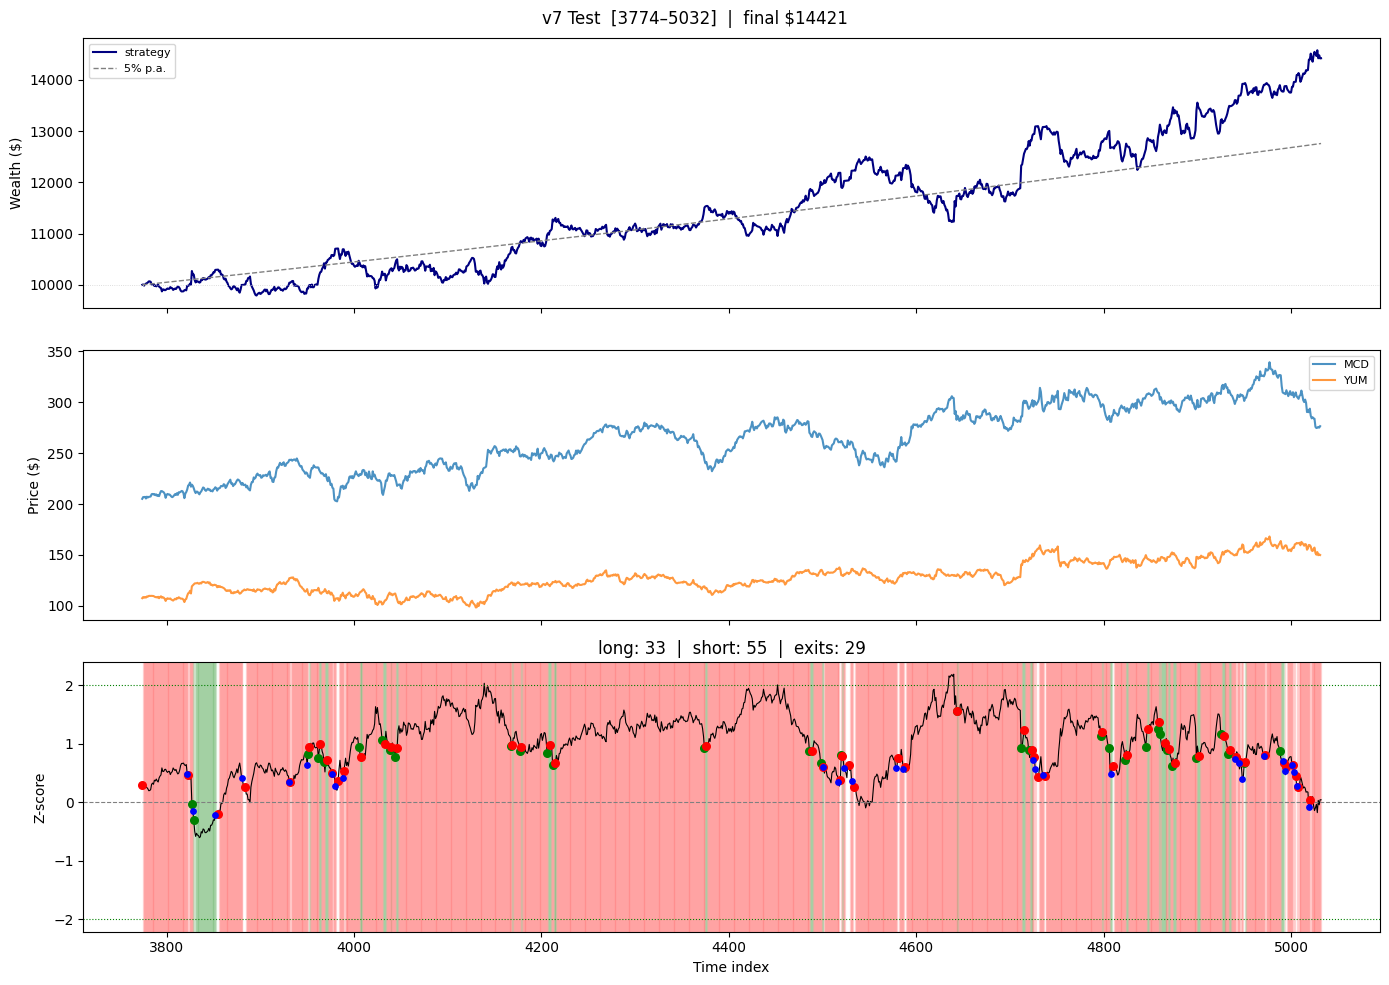

In [9]:
# ── Evaluation on real data (fixed z normalisation) ──────────────────────
# Use full price array; pin t_start/t_end manually
real_env = PairTradingEnv(
    prices=prices, beta=beta, intercept=intercept,
    z_mean=train_mean, z_std=train_std,
)

print('=== Test set ===')
res_test = evaluate(real_env, agent, t_start=train_end, t_end=N)
m_test   = metrics(res_test['wealth'], 'DDQN v7 (50/50 synthetic+real) — test')
plot_results(res_test, title=f'v7 Test  [{train_end}–{N}]  |  final ${res_test["wealth"][-1]:.0f}')

=== Training windows ===
Train yr 1  [3–255]                                 final $   10963  ret   +9.6%  Sharpe  1.03  MDD  -10.1%


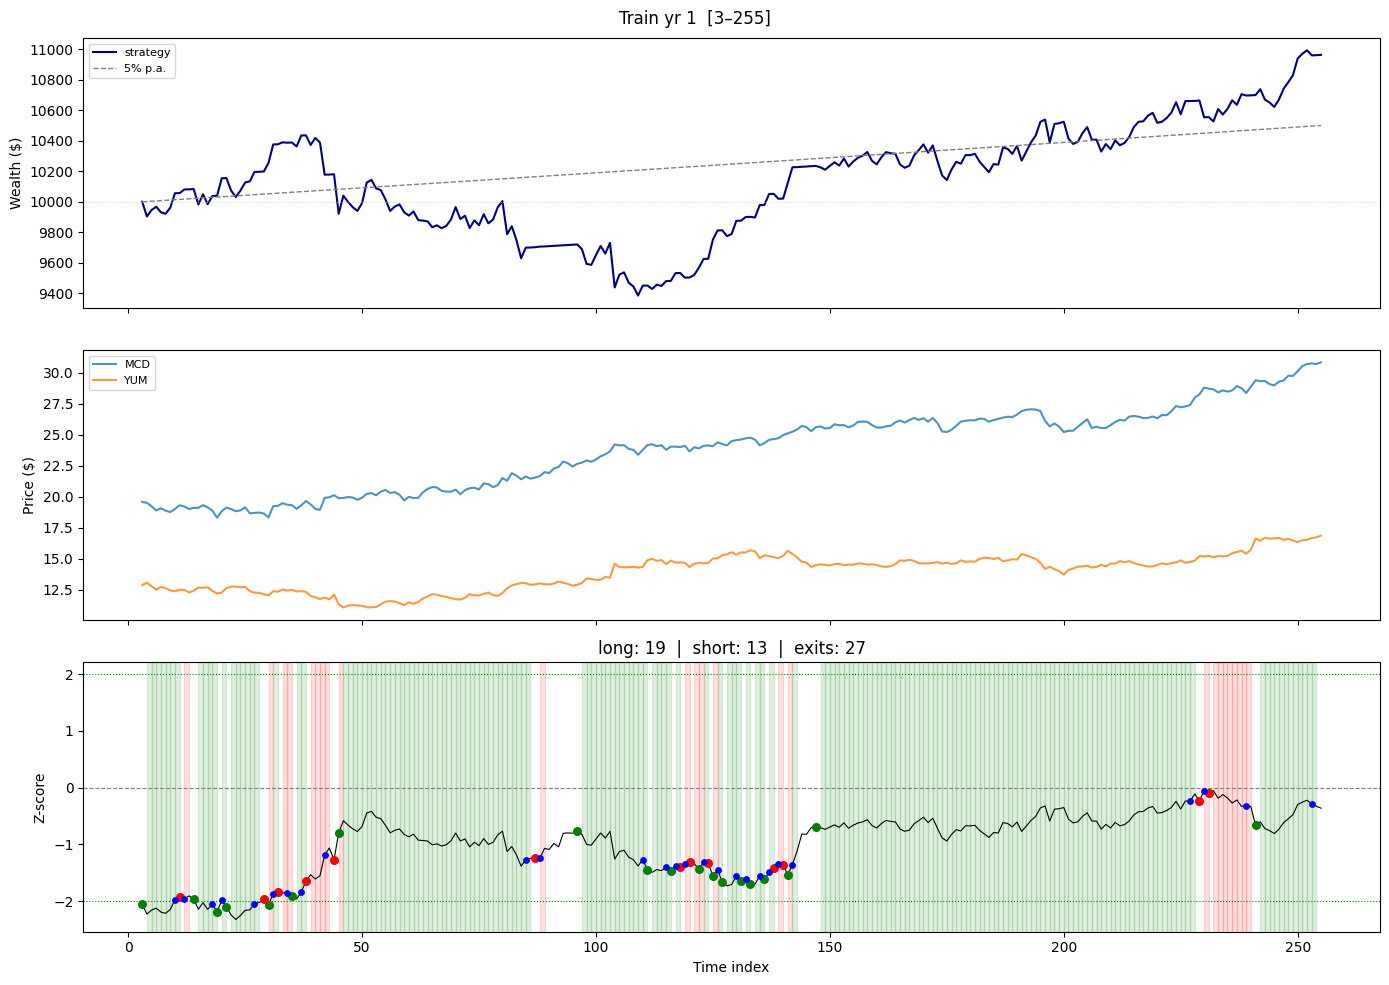

Train yr 2  [255–507]                               final $   14592  ret  +45.9%  Sharpe  3.01  MDD   -3.3%


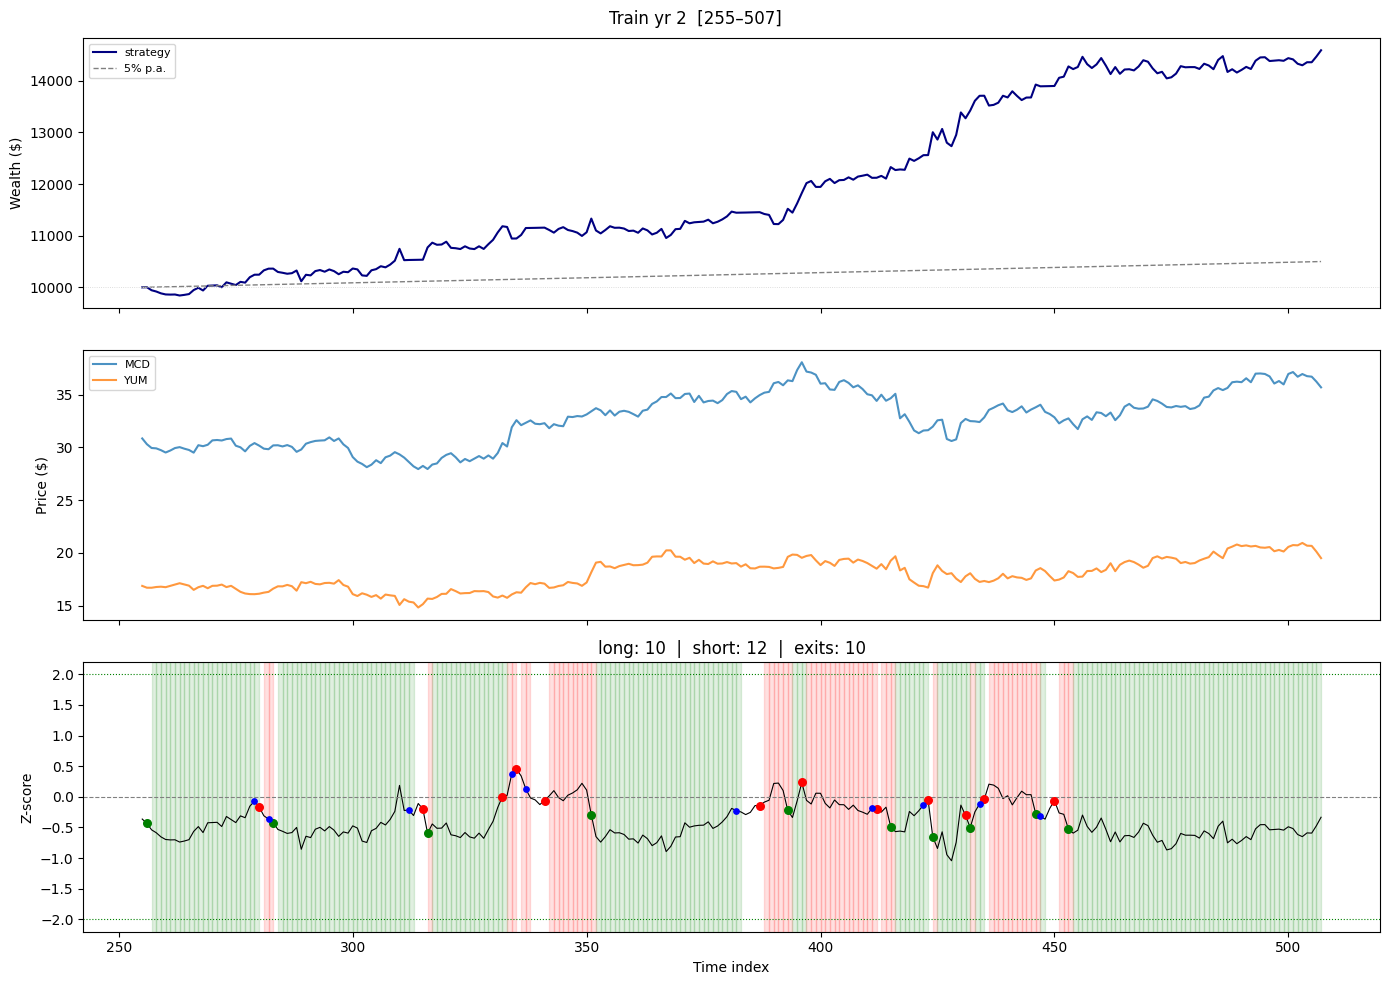

Train yr 3  [507–759]                               final $   10869  ret   +8.7%  Sharpe  0.65  MDD  -10.8%


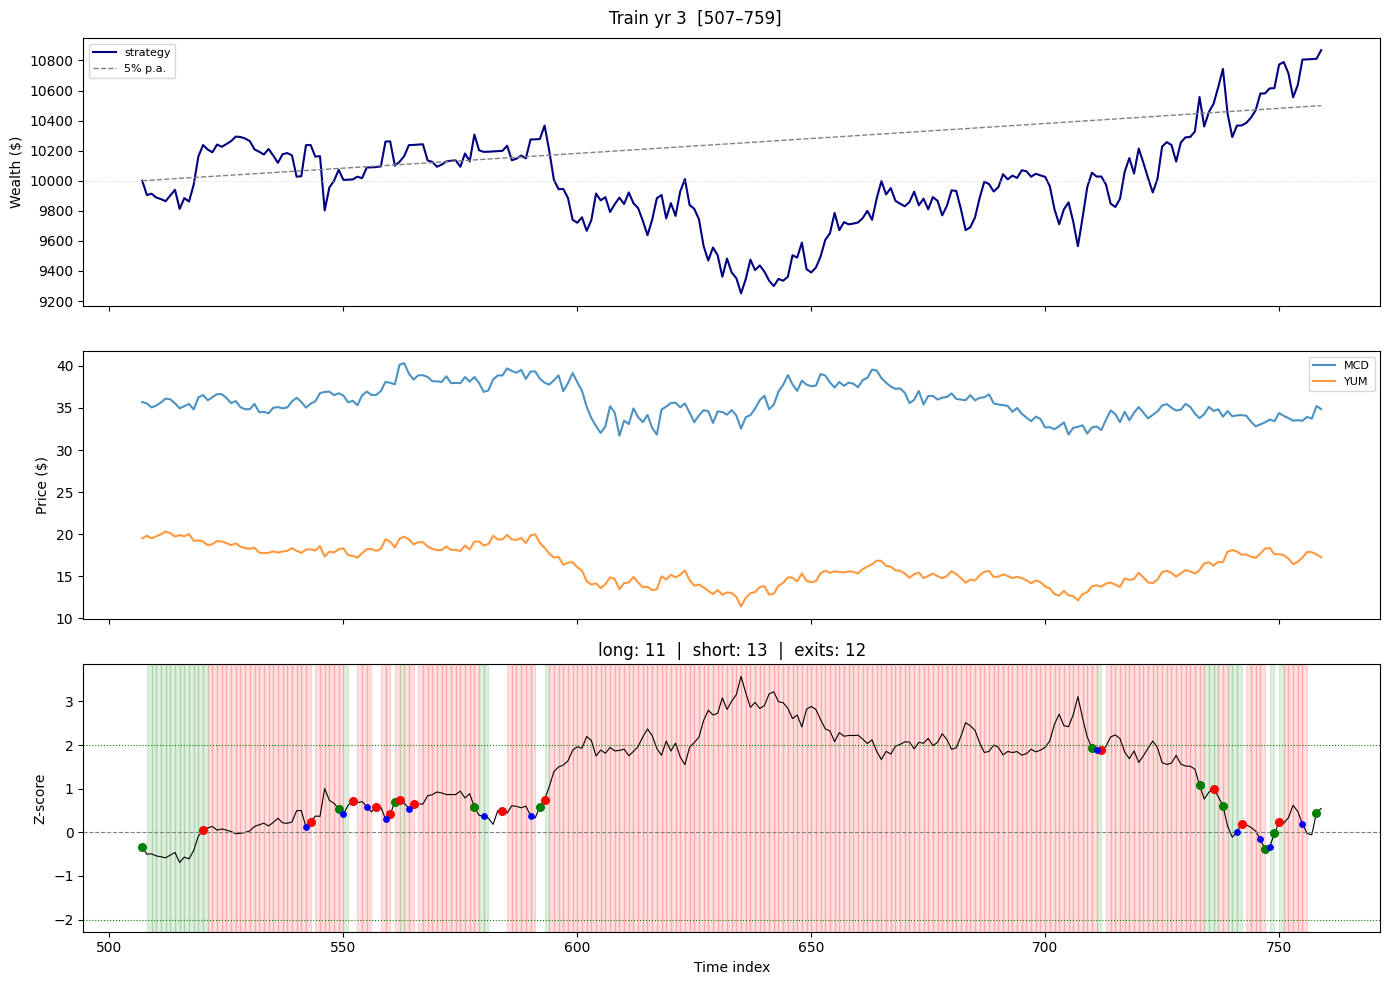

Train yr 4  [759–1011]                              final $   11114  ret  +11.1%  Sharpe  1.14  MDD   -5.5%


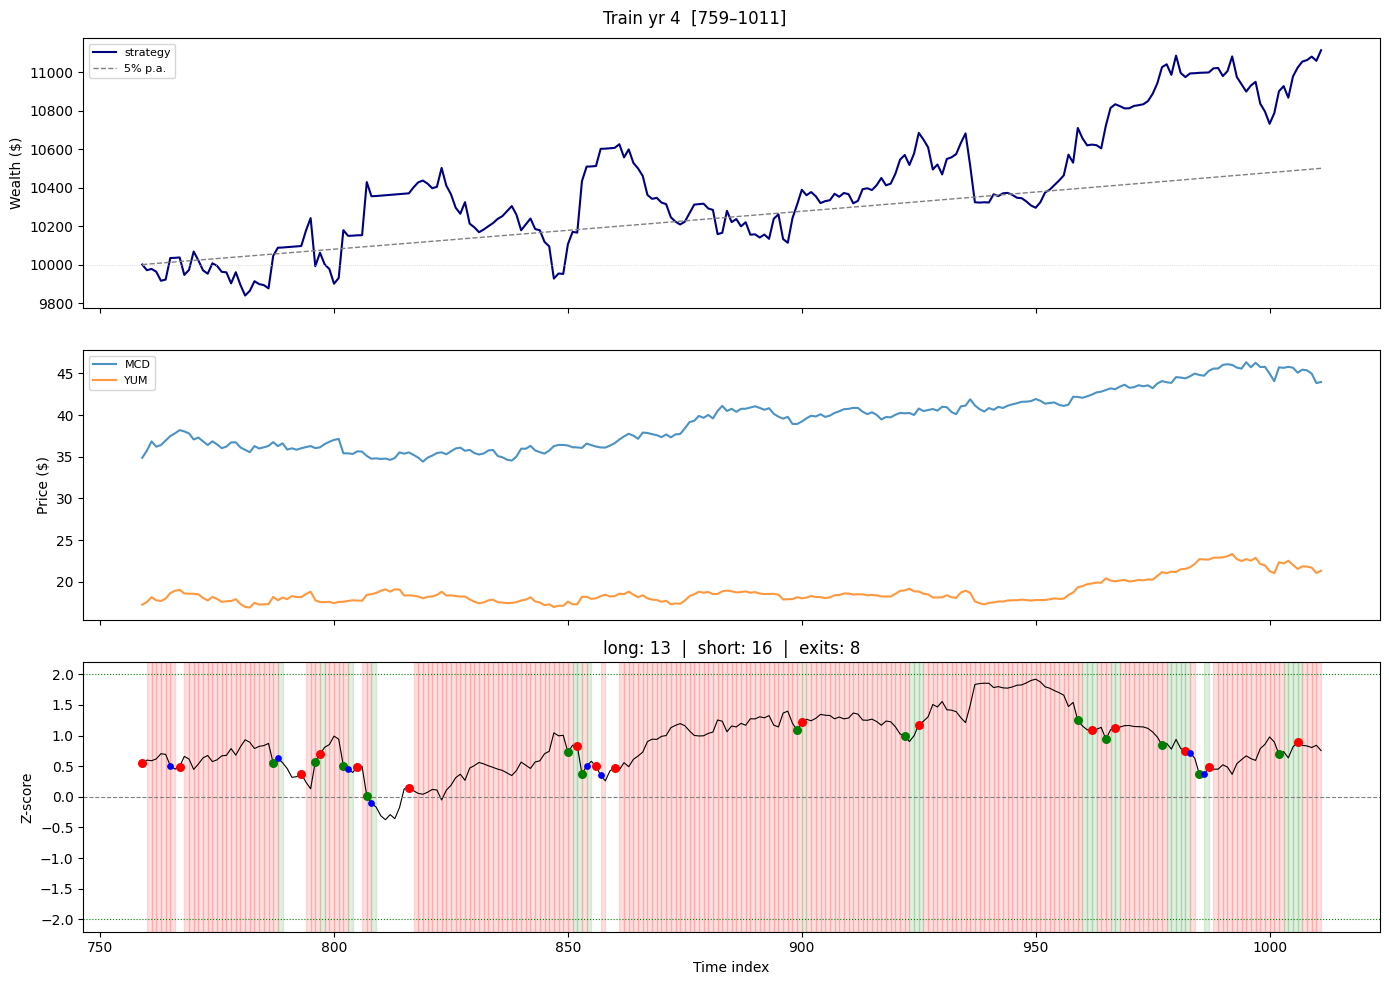

In [10]:
# ── Behaviour on training windows ────────────────────────────────────────
print('=== Training windows ===')
win = 252
for k in range(4):
    t0 = real_env._min_t + k * win
    t1 = t0 + win
    if t1 > train_end:
        break
    res_tr = evaluate(real_env, agent, t_start=t0, t_end=t1)
    label  = f'Train yr {k+1}  [{t0}–{t1}]'
    metrics(res_tr['wealth'], label)
    plot_results(res_tr, title=label)

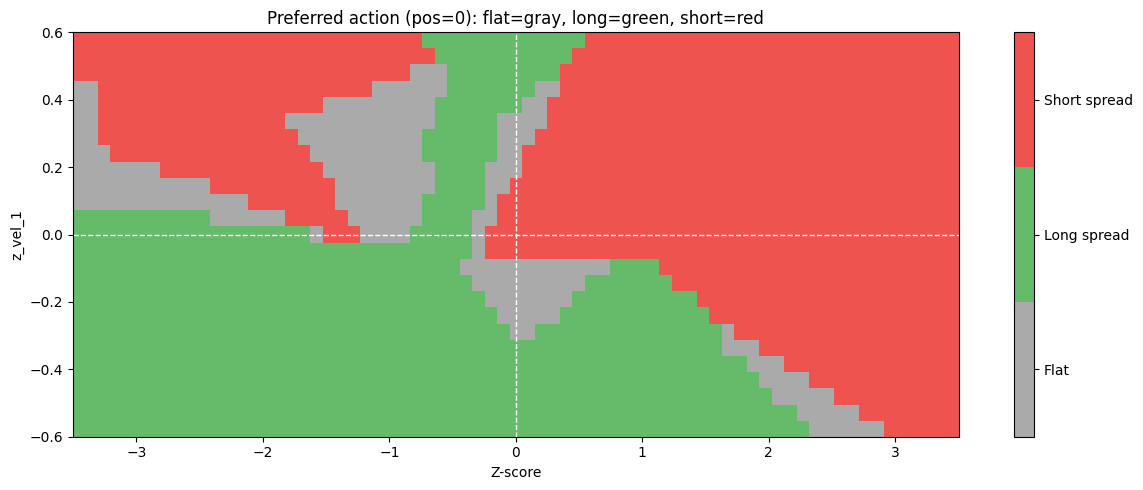

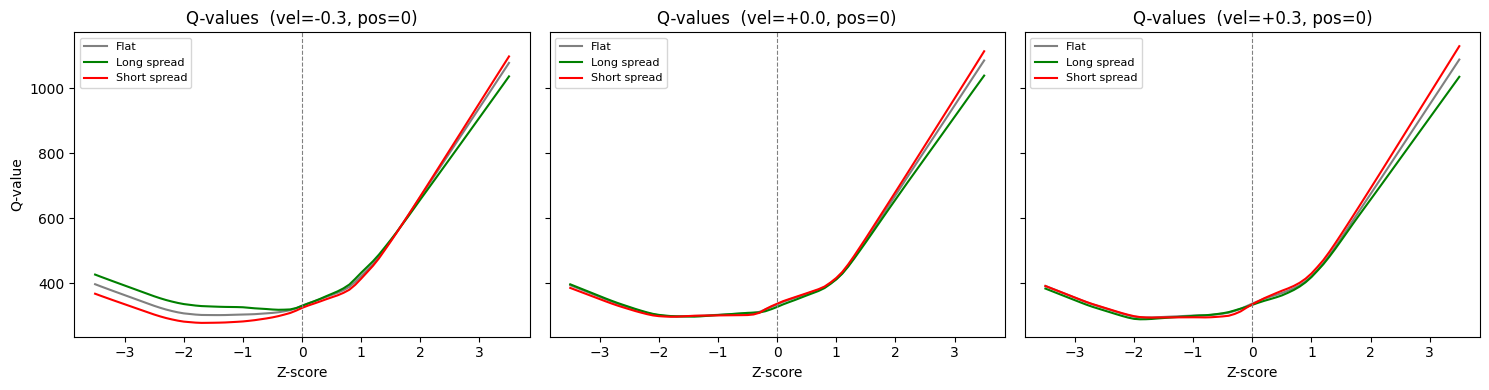

In [11]:
# ── Network interpretation ────────────────────────────────────────────────
ACT_LABELS = ['Flat', 'Long spread', 'Short spread']
ACT_COLORS = ['gray', 'green', 'red']

z_vals   = np.linspace(-3.5, 3.5, 71)
vel_vals = np.linspace(-0.6, 0.6, 25)

agent.q_net.eval()
action_grid = np.zeros((len(vel_vals), len(z_vals)), dtype=int)

with torch.no_grad():
    for i, v in enumerate(vel_vals):
        for j, z in enumerate(z_vals):
            obs = np.array([z, 0.0, v, v * 2.0], dtype=np.float32)
            s   = torch.from_numpy(obs).unsqueeze(0)
            action_grid[i, j] = int(agent.q_net(s).argmax().item())

agent.q_net.train()

cmap = plt.matplotlib.colors.ListedColormap(['#aaaaaa', '#66bb6a', '#ef5350'])
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(
    action_grid, aspect='auto', origin='lower', cmap=cmap, vmin=-0.5, vmax=2.5,
    extent=[z_vals[0], z_vals[-1], vel_vals[0], vel_vals[-1]],
)
ax.set_xlabel('Z-score')
ax.set_ylabel('z_vel_1')
ax.set_title('Preferred action (pos=0): flat=gray, long=green, short=red')
ax.axvline(0, color='white', lw=1, ls='--')
ax.axhline(0, color='white', lw=1, ls='--')
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.set_ticklabels(ACT_LABELS)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, v_fix in zip(axes, [-0.3, 0.0, 0.3]):
    q_vals = np.zeros((len(z_vals), 3))
    with torch.no_grad():
        for j, z in enumerate(z_vals):
            obs = np.array([z, 0.0, v_fix, v_fix * 2.0], dtype=np.float32)
            s   = torch.from_numpy(obs).unsqueeze(0)
            q_vals[j] = agent.q_net(s).numpy()[0]
    for k, (lbl, col) in enumerate(zip(ACT_LABELS, ACT_COLORS)):
        ax.plot(z_vals, q_vals[:, k], label=lbl, color=col, lw=1.5)
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel('Z-score')
    ax.set_title(f'Q-values  (vel={v_fix:+.1f}, pos=0)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Q-value')
plt.tight_layout()
plt.show()

In [12]:
import os
os.makedirs('../models', exist_ok=True)
agent.save('../models/mcd_yum_ddqn_v7.pt')
print('Model saved.')

Model saved.
